# DAY2 — 충전 프로토콜을 분리한 검증

기존 초기 특징을 재사용해 특징 추가·제거·규제·학습 손실을 프로토콜 CV에서 다시 비교한다. 학습과 Hold-out 및 프로토콜 CV의 각 학습·검증 폴드에 동일 충전 조합이 겹치지 않는다. Batch2 결과를 보고 후보를 다시 선택하지 않는다.

**보고서 연결:** 이 노트북은 해당 실험 단계의 실행 기록이다. 기존 셀 분리와 프로토콜 분리 결과를 함께 해석한 전체 결론은 [DAY2 보고서](../outputs/day2/DAY2_REPORT.md)에 있다.


In [1]:
from pathlib import Path
import sys, json
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd().resolve()
if not (ROOT / "src/day2_protocol_validation.py").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.day2_protocol_validation import main
main()  # 완료된 결과가 있으면 학습·평가 없이 보고서를 재생성
OUT = ROOT / "outputs/day2/protocol_validation"
result = json.loads((OUT / "results.json").read_text())
plan = json.loads((OUT / "plan.json").read_text())
print("선택 후보:", result["primary"])
display(pd.DataFrame([plan["versions"]]))

Completed protocol validation exists; no repeated training or scoring.
              candidate               evaluation  n  mape_pct     mae    rmse     r2
S3_elasticnet_0.001_0.5 Valid (Batch 1 Hold-out)  7     8.923  71.667  90.773  0.728
S3_elasticnet_0.001_0.5           Test (Batch 2) 39    37.138 197.703 217.063  0.021
              S0_linear Valid (Batch 1 Hold-out)  7    10.728  88.270  96.290  0.694
              S0_linear           Test (Batch 2) 39    28.685 142.757 159.825  0.469
 control_five_log_ridge Valid (Batch 1 Hold-out)  7     8.127  65.113  82.220  0.777
 control_five_log_ridge           Test (Batch 2) 39    39.545 208.573 226.423 -0.066
      control_five_mape Valid (Batch 1 Hold-out)  7     9.940  85.348 109.167  0.607
      control_five_mape           Test (Batch 2) 39    33.842 174.036 190.800  0.243
선택 후보: S3_elasticnet_0.001_0.5


,python,numpy,pandas,scikit_learn,joblib
0,3.11.15,2.4.6,3.0.6,1.9.1,1.6.0


## 1. 분할과 두 검증 방식

동일 개발 셀에서 셀 KFold와 프로토콜 GroupKFold를 비교한다. Hold-out은 GroupShuffleSplit으로 보관하며 seed42의 한 분할을 유지한다.

In [2]:
manifest = pd.read_csv(OUT / "split_manifest.csv")
display(manifest.groupby("role").agg(셀수=("cell_id", "size"), 프로토콜수=("protocol", "nunique")))
assert not set(manifest.loc[manifest.role.eq("development"), "protocol"]) & set(manifest.loc[manifest.role.eq("holdout"), "protocol"])
folds = pd.read_csv(OUT / "fold_metrics.csv")
assert folds.loc[folds.method.eq("protocol"), "protocol_overlap"].eq(0).all()
print("프로토콜 중복 확인: Hold-out 및 CV 모두 0")

,셀수,프로토콜수
role,,
development,29,16
holdout,7,4


프로토콜 중복 확인: Hold-out 및 CV 모두 0


## 2. 특징 추가 과정

S0 분산 → S1 로그 수명 → S2 최솟값 → S3 초기 용량·변화율·기울기 → S4 저항 → S5 온도 → S6 충전시간 → S7 충전 조건. F1은 DAY1의 최초 추가 특징 제안이다. 단계별 점수는 각 방식에서 고른 후보의 CV다.

In [3]:
stages = pd.read_csv(OUT / "stage_comparison.csv")
display(stages.pivot(index="stage", columns="method", values="cv_mape_pct").round(3))
cv = pd.read_csv(OUT / "model_comparison.csv")
display(cv.loc[cv.candidate.eq(result["primary"]), ["candidate", "method", "cv_mape_pct", "cv_std_pct"]].round(3))

method,cell,protocol
stage,,
F1,9.403,8.437
S0,8.833,7.929
S1,9.072,8.239
S2,8.736,7.937
S3,5.770,5.683
S4,6.046,5.704
S5,6.147,6.505
S6,6.834,7.054
S7,5.906,6.654


,candidate,method,cv_mape_pct,cv_std_pct
52,S3_elasticnet_0.001_0.5,cell,5.770,1.764
53,S3_elasticnet_0.001_0.5,protocol,5.683,2.031


## 3. 특징 제거·규제·학습 손실

프로토콜 CV에서 고른 특징 집합을 기준으로 후보를 추가 비교했다. 비교 규칙과 후보 선택을 평가 전에 고정했다. 모든 전처리는 각 학습 폴드에서만 fit한다.

In [4]:
display(cv.loc[cv.method.eq("protocol") & cv.phase.eq("refinement")].sort_values("cv_mape_pct").head(10)[["candidate", "n_features", "cv_mape_pct", "cv_std_pct"]].round(3))
display(pd.read_csv(OUT / "selected_coefficients.csv").round(6))

,candidate,n_features,cv_mape_pct,cv_std_pct
163,R_ridge_full_a0.1,5,5.919,2.096
235,R_ridge_minus_early_drop_per100_a0.1,4,5.974,2.120
217,R_ridge_minus_qd_fraction_change_a0.1,4,6.032,2.126
233,R_mape_raw_minus_qd_fraction_change_a0.1,4,6.257,3.243
179,R_mape_raw_full_a0.1,5,6.257,3.243
251,R_mape_raw_minus_early_drop_per100_a0.1,4,6.257,3.243
237,R_ridge_minus_early_drop_per100_a1,4,6.458,1.773
227,R_mae_raw_minus_qd_fraction_change_a0.1,4,6.462,2.781
173,R_mae_raw_full_a0.1,5,6.462,2.781
245,R_mae_raw_minus_early_drop_per100_a0.1,4,6.462,2.781


,feature,standardized_coefficient,nonzero
0,log10_delta_Q_var,-0.000000,False
1,delta_Q_min,0.077190,True
2,qd_initial_median,0.030426,True
3,qd_fraction_change,-0.007636,True
4,early_drop_per100,0.000000,False


## 4. Hold-out 및 Batch2 평가

선택 후보와 기준 모델은 같은 개발29셀로 학습했다. 원논문9.1%는 조건이 다른 과제 참고값이다. Gap은 %p로 표시한다.

,candidate,n_features,cv_mape_pct,Test (Batch 2),Valid (Batch 1 Hold-out)
0,S0_linear,1,7.929,28.685,10.728
1,S3_elasticnet_0.001_0.5,5,5.683,37.138,8.923
2,control_five_log_ridge,5,6.498,39.545,8.127
3,control_five_mape,5,7.180,33.842,9.940


,구분,MAPE (%),비고
0,Train (Batch 1 CV),5.683,프로토콜 단위 5-fold 검증 평균
1,Valid (Batch 1 Hold-out),8.923,7셀·4개 미관측 프로토콜
2,Test (Batch 2),37.138,39셀; 이전 열람 이력이 있는 후속 평가
3,Gap (Train-Valid),3.241,Valid − CV; %p
4,Gap (Valid-Test),28.215,Test − Valid; %p
5,Gap (Target-Test),28.038,Test − 과제 참고값9.1%; %p


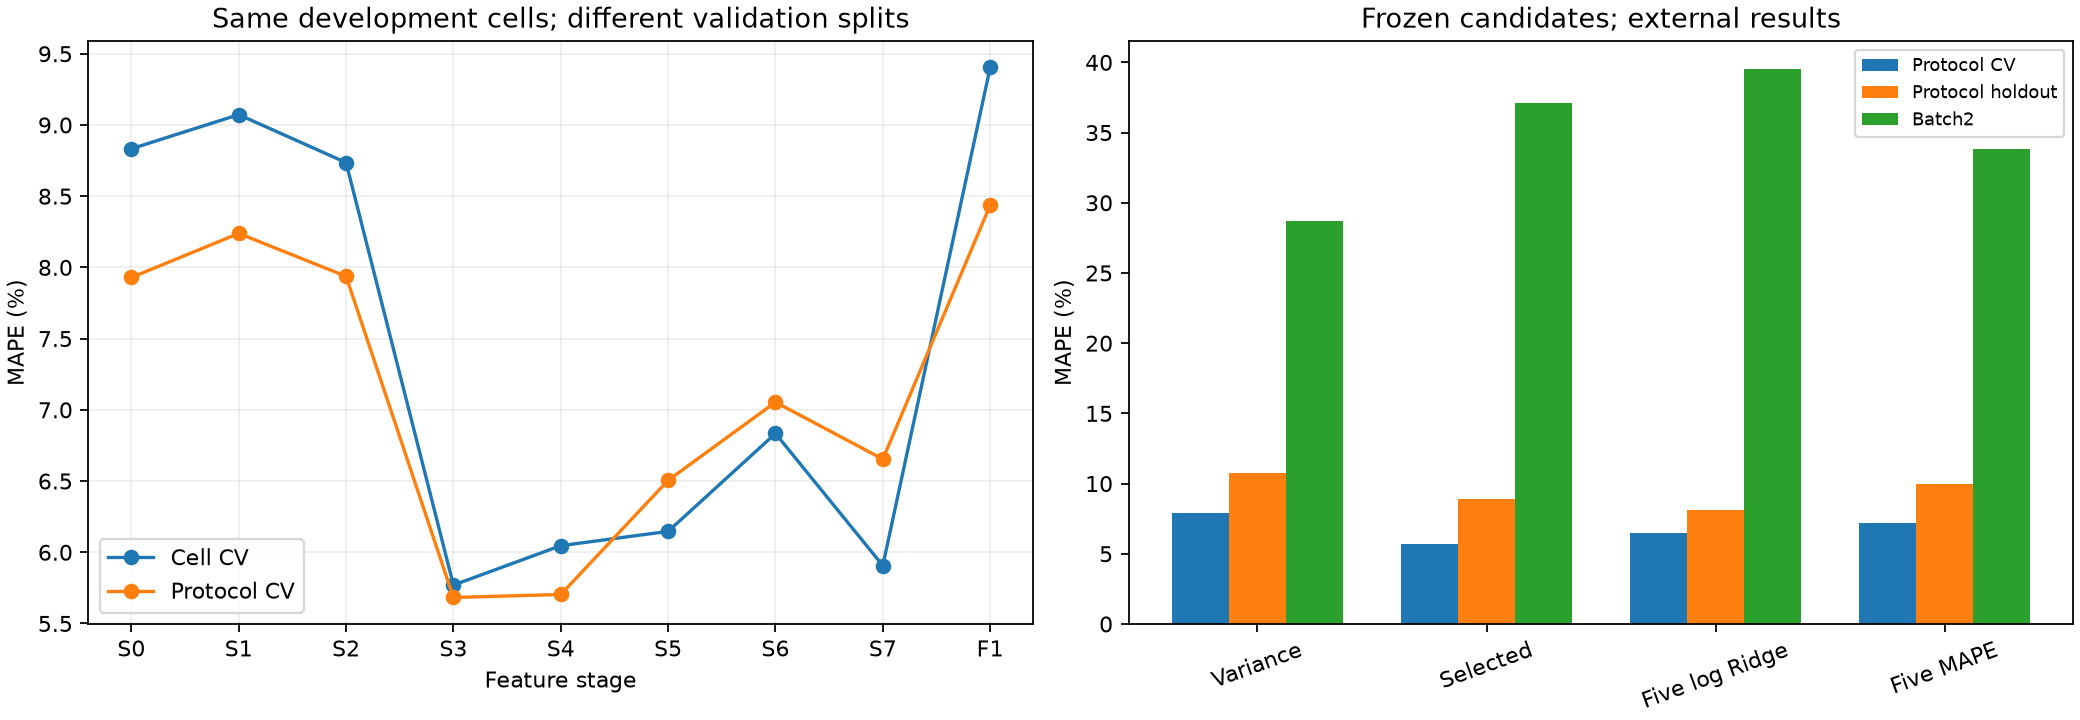

,candidate,grouping,segment,n,mape_pct,mean_overprediction
0,S3_elasticnet_0.001_0.5,protocol,unseen,37,36.641,177.449
1,S3_elasticnet_0.001_0.5,protocol,seen,2,46.335,185.515
2,S3_elasticnet_0.001_0.5,life,<=500,28,38.918,173.284
3,S3_elasticnet_0.001_0.5,life,500-1000,8,37.593,272.654
4,S3_elasticnet_0.001_0.5,life,>1000,3,19.317,-32.185
5,S0_linear,protocol,unseen,37,28.087,126.115
6,S0_linear,protocol,seen,2,39.752,158.949
7,S0_linear,life,<=500,28,32.837,145.801
8,S0_linear,life,500-1000,8,22.080,145.187
9,S0_linear,life,>1000,3,7.549,-86.592


In [5]:
display(pd.read_csv(OUT / "summary.csv").round(3))
display(pd.read_csv(OUT / "performance_reporting.csv").round(3))
display(Image(filename=str(OUT / "comparison.png")))
display(pd.read_csv(OUT / "evaluation_segments.csv").round(3))

## 5. 결론과 한계

프로토콜을 분리해도 두 CV 방식이 같은 후보를 골랐다. 선택 후보는 프로토콜 Hold-out에서 기준 모델보다 좋았지만 Batch2에서는 나빴다. 프로토콜 중복만으로 기존 배치 간 성능 저하를 설명할 수 없다. 단수명 학습 범위 부족과 배치별 상태·특징 관계 차이가 함께 남는다.

이번 학습 기준 Batch2의 익숙한 조합은2셀, 새로운 조합은37셀이다. 익숙한 조합 집단이 너무 작아 신규성의 독립적 영향을 비교하기 어렵다. 입력은5개지만 최종 Elastic Net의 비영 계수는3개다. 분산과 초기 기울기 계수는0이며, 이는 중복 정보 선택 결과이지 물리적 중요성을 부정하는 결과가 아니다.

Batch1의 기존 셀과 이미 여러 번 본 Batch2를 재사용한 후속 탐색이다. CV에도 후보 선택의 편향이 남는다. Batch2 결과로 재선택하지 않고, Hold-out 포함 전체 재학습이나 Batch3 평가도 수행하지 않았다.

보고서: `outputs/day2/DAY2_PROTOCOL_VALIDATION.md`. 실행 코드: `src/day2_protocol_validation.py`.

## 전체 결과를 종합한 최종 추천

이 노트북은 당시 CV 선택·평가 기록을 유지한다. 이후 **단일 분산 선형회귀(`S0_linear`, 개발 29셀)**를 최종 추천으로 정했다. Batch2 **28.68%**, Batch3 **12.09%**의 관측 성능과 단순성을 고려한 판단이다. 외부 결과를 참고한 사후 추천이며 모델 재학습이나 기존 예측 변경은 없다. [DAY2 보고서](../outputs/day2/DAY2_REPORT.md)와 [추천 모델 기록](../outputs/day2/final_recommendation/recommendation.json)을 참고한다.